# 📈 Meta-Labeling — ML Training

Loads pre-built trade+feature data from `feature_pipeline_001.ipynb` and trains
three calibrated classifiers (XGBoost, LightGBM, CatBoost) with purged CV.

**Prerequisites**: run `feature_pipeline_001.ipynb` first to generate:
- `all_trades_with_features.h5`
- `feature_columns.json`


In [ ]:
import sys, os, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100


In [ ]:
# ── Load pipeline outputs (run feature_pipeline_001.ipynb first) ─────────
training_df = pd.read_hdf('all_trades_with_features.h5', 'data')
training_df['entry_date'] = pd.to_datetime(training_df['entry_date'])
training_df['exit_date']  = pd.to_datetime(training_df['exit_date'])
training_df = training_df.sort_values('entry_date').reset_index(drop=True)

with open('feature_columns.json') as f:
    training_feature_columns = json.load(f)

# Filter to columns that actually exist (guard against schema drift)
training_feature_columns = [c for c in training_feature_columns if c in training_df.columns]

print(f'Trades loaded  : {len(training_df):,}')
print(f'Date range     : {training_df["entry_date"].min().date()} → {training_df["entry_date"].max().date()}')
print(f'Win rate       : {training_df["Y"].mean():.2%}')
print(f'Feature count  : {len(training_feature_columns)}')


# 7. Time-Ordered Train/Test Split

## 🚨 Most Critical Fix

**Original notebook:**
```python
train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)  # WRONG!
```

This randomly mixes time periods — your model trains on 2023 data and tests on 2018 data, which is **future-leakage in reverse**. Backtest results look great but live trading collapses.

**Correct approach:** Split chronologically. Train on past, test on future.


In [242]:
# === Chronological split (no shuffle!) ===
TRAIN_END_DATE = '2022-06-30'   # ~80/20 split (2014-2022 train, 2022-2023 test)
EMBARGO_DAYS   = 10              # gap between train and test

train_mask = training_df['entry_date'] <= pd.Timestamp(TRAIN_END_DATE)
embargo_start = pd.Timestamp(TRAIN_END_DATE)
embargo_end   = embargo_start + pd.Timedelta(days=EMBARGO_DAYS)
test_mask = training_df['entry_date'] > embargo_end

X_train = training_df.loc[train_mask, training_feature_columns].copy()
y_train = training_df.loc[train_mask, 'Y'].copy()
X_test  = training_df.loc[test_mask,  training_feature_columns].copy()
y_test  = training_df.loc[test_mask,  'Y'].copy()
returns_test = training_df.loc[test_mask, 'net_return'].copy()
dates_train  = training_df.loc[train_mask, 'entry_date'].copy()
dates_test   = training_df.loc[test_mask,  'entry_date'].copy()
exit_dates_train = training_df.loc[train_mask, 'exit_date'].copy()

print(f"Train period: {dates_train.min()} → {dates_train.max()} ({len(X_train)} trades)")
print(f"  → Embargo: {embargo_start.date()} to {embargo_end.date()} ({EMBARGO_DAYS} days)")
print(f"Test period:  {dates_test.min()} → {dates_test.max()} ({len(X_test)} trades)")
print(f"\nTrain label balance: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Test label balance:  {y_test.value_counts(normalize=True).to_dict()}")

Train period: 2017-05-22 00:00:00 → 2022-06-30 00:00:00 (7780 trades)
  → Embargo: 2022-06-30 to 2022-07-10 (10 days)
Test period:  2022-07-12 00:00:00 → 2026-04-06 00:00:00 (6121 trades)

Train label balance: {0: 0.6051413881748072, 1: 0.39485861182519283}
Test label balance:  {0: 0.6322496324130044, 1: 0.3677503675869956}


In [243]:
# === Scaling — fit on train ONLY, transform test ===
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

# 🚨 NOTE: We do NOT use SMOTE.
# SMOTE creates synthetic samples by interpolating between neighbors —
# this doesn't make sense for time-series financial data and can leak info.
# Instead, we use class_weight='balanced' or scale_pos_weight in models.

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

X_train_scaled: (7780, 43)
X_test_scaled:  (6121, 43)


# 8. Compute Sample Uniqueness Weights

When trades have **overlapping holding periods**, their labels are not independent — they share return information. López de Prado's solution: **down-weight overlapping samples** during training.


In [244]:
def compute_sample_uniqueness(entry_dates: pd.Series, exit_dates: pd.Series) -> np.ndarray:
    """
    Compute López de Prado's sample uniqueness:
    For each sample, count how many other samples' [entry, exit] intervals overlap with it.
    Weight = 1 / overlap_count (then normalized).
    """
    n = len(entry_dates)
    entries = entry_dates.values
    exits   = exit_dates.values
    overlaps = np.zeros(n)

    for i in range(n):
        # Count concurrent samples (including self)
        overlaps[i] = ((entries <= exits[i]) & (exits >= entries[i])).sum()

    weights = 1.0 / np.maximum(overlaps, 1)
    return weights / weights.mean()  # normalize to mean=1


train_weights = compute_sample_uniqueness(
    dates_train.reset_index(drop=True),
    exit_dates_train.reset_index(drop=True),
)

print(f"Train sample weights:")
print(f"  min:    {train_weights.min():.3f}")
print(f"  median: {np.median(train_weights):.3f}")
print(f"  max:    {train_weights.max():.3f}")
print(f"  Effective sample size: {(train_weights.sum())**2 / (train_weights**2).sum():.0f} / {len(train_weights)}")

Train sample weights:
  min:    0.042
  median: 0.951
  max:    7.045
  Effective sample size: 6470 / 7780


# 9. Purged & Embargoed K-Fold Cross-Validation

## Why?

Standard `KFold` randomly shuffles → leakage.
Standard `TimeSeriesSplit` doesn't purge overlapping samples.

**Purged & Embargoed K-Fold** (López de Prado, AFML Ch. 7):
- Splits data chronologically
- **Purges** training samples whose holding period overlaps the test set
- **Embargo**: removes samples right after the test fold to prevent serial-correlation leakage


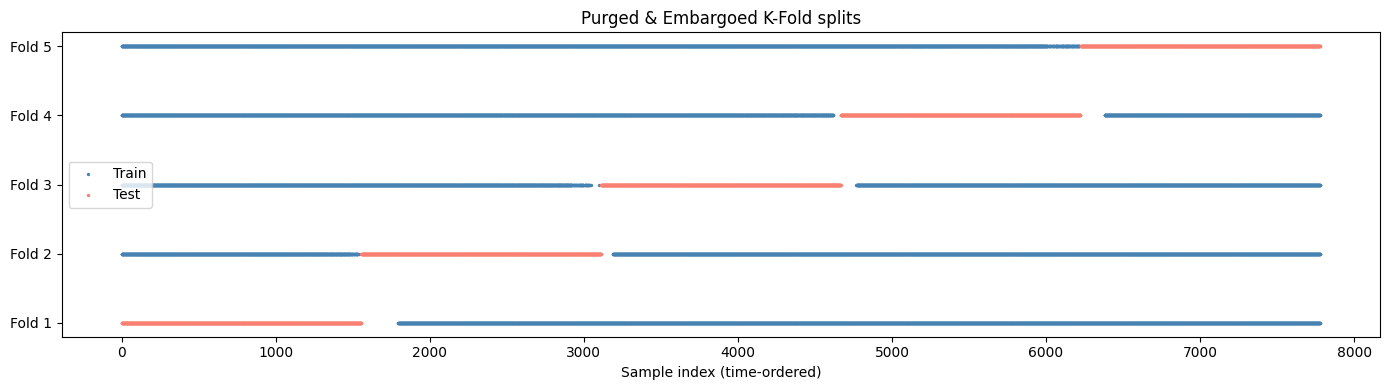

In [245]:
class PurgedKFold:
    """
    Purged & Embargoed K-Fold for time-series with overlapping labels.

    Parameters
    ----------
    n_splits : int
    entry_dates : pd.Series of trade entry timestamps
    exit_dates  : pd.Series of trade exit timestamps
    embargo_pct : float, fraction of dataset to embargo after each test fold
    """
    def __init__(self, n_splits=5, entry_dates=None, exit_dates=None, embargo_pct=0.01):
        self.n_splits    = n_splits
        self.entry_dates = entry_dates.reset_index(drop=True)
        self.exit_dates  = exit_dates.reset_index(drop=True)
        self.embargo_pct = embargo_pct

    def split(self, X, y=None, groups=None):
        n = len(X)
        indices = np.arange(n)
        embargo_n = int(n * self.embargo_pct)

        # Test folds are contiguous chunks ordered in time
        test_ranges = np.array_split(indices, self.n_splits)

        for test_idx in test_ranges:
            test_start_t = self.entry_dates.iloc[test_idx[0]]
            test_end_t   = self.exit_dates.iloc[test_idx[-1]]

            train_mask = np.ones(n, dtype=bool)
            train_mask[test_idx] = False

            # Purge: remove training samples whose [entry, exit] overlaps test period
            for i in indices[train_mask]:
                if (self.entry_dates.iloc[i] <= test_end_t) and \
                   (self.exit_dates.iloc[i]  >= test_start_t):
                    train_mask[i] = False

            # Embargo: remove samples right after test fold
            embargo_end = min(test_idx[-1] + 1 + embargo_n, n)
            train_mask[test_idx[-1]+1 : embargo_end] = False

            train_idx = indices[train_mask]
            yield train_idx, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


# === Build CV splitter for training set ===
purged_cv = PurgedKFold(
    n_splits=5,
    entry_dates=dates_train,
    exit_dates=exit_dates_train,
    embargo_pct=0.01,
)

# Sanity check: visualize splits
fig, ax = plt.subplots(figsize=(14, 4))
for fold, (tr, te) in enumerate(purged_cv.split(X_train_scaled)):
    ax.scatter(tr, [fold]*len(tr), c='steelblue', s=2, label='Train' if fold==0 else None)
    ax.scatter(te, [fold]*len(te), c='salmon',    s=2, label='Test'  if fold==0 else None)
ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_xlabel('Sample index (time-ordered)')
ax.set_title('Purged & Embargoed K-Fold splits')
ax.legend()
plt.tight_layout()
plt.show()

# 10. Evaluation Helpers

We evaluate models with metrics that matter for **trading P&L**, not just classification accuracy:
- **AUC** — discrimination ability
- **Precision @ threshold** — how often "predicted win" is actually a win
- **Sharpe lift** — improvement in risk-adjusted return when using model as a filter
- **Trade reduction** — % of bad trades successfully filtered


In [246]:
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, brier_score_loss,
)


def evaluate_meta_model(
    y_true: pd.Series,
    y_proba: np.ndarray,
    returns: pd.Series,
    threshold: float = 0.55,
) -> dict:
    """Compute trading-relevant evaluation metrics."""
    y_pred = (y_proba >= threshold).astype(int)

    # Filter strategy returns: only take trades where model says "win"
    take_mask = y_pred == 1
    base_returns     = returns
    filtered_returns = returns[take_mask]

    def sharpe(r):
        return r.mean() / (r.std() + 1e-9) * np.sqrt(252) if len(r) > 1 else 0

    metrics = {
        'auc':              roc_auc_score(y_true, y_proba),
        'brier_score':      brier_score_loss(y_true, y_proba),
        'precision':        precision_score(y_true, y_pred, zero_division=0),
        'recall':           recall_score(y_true, y_pred, zero_division=0),
        'f1':               f1_score(y_true, y_pred, zero_division=0),
        'trades_taken':     int(take_mask.sum()),
        'trades_filtered':  int((~take_mask).sum()),
        'pct_filtered':     float((~take_mask).mean()),
        'base_mean_ret':    float(base_returns.mean()),
        'filt_mean_ret':    float(filtered_returns.mean()) if len(filtered_returns) else 0,
        'base_sharpe':      sharpe(base_returns),
        'filt_sharpe':      sharpe(filtered_returns) if len(filtered_returns) > 1 else 0,
    }
    metrics['sharpe_lift'] = metrics['filt_sharpe'] - metrics['base_sharpe']
    return metrics


def plot_evaluation(model_name, y_true, y_proba, returns, threshold=0.55):
    metrics = evaluate_meta_model(y_true, y_proba, returns, threshold)
    y_pred = (y_proba >= threshold).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred Loss', 'Pred Win'],
                yticklabels=['Actual Loss', 'Actual Win'])
    axes[0].set_title(f'{model_name} — Confusion @ thr={threshold}')

    # Probability distribution
    axes[1].hist(y_proba[y_true==0], bins=30, alpha=0.5, label='Actual Loss', color='red')
    axes[1].hist(y_proba[y_true==1], bins=30, alpha=0.5, label='Actual Win',  color='green')
    axes[1].axvline(threshold, color='black', linestyle='--', label=f'thr={threshold}')
    axes[1].set_xlabel('Predicted P(win)')
    axes[1].set_title(f'{model_name} — Probability Distribution')
    axes[1].legend()

    # Returns: filtered vs base
    rets_base = returns
    rets_filt = returns[y_pred==1]
    axes[2].hist(rets_base, bins=40, alpha=0.4, label=f'All (μ={rets_base.mean():.2%})', color='gray')
    if len(rets_filt) > 0:
        axes[2].hist(rets_filt, bins=40, alpha=0.6,
                     label=f'Filtered (μ={rets_filt.mean():.2%})', color='green')
    axes[2].axvline(0, color='black', linestyle='-', alpha=0.3)
    axes[2].set_xlabel('Net Return')
    axes[2].set_title(f'{model_name} — Return Distributions')
    axes[2].legend()

    plt.tight_layout()
    plt.show()
    return metrics

# 11. Train XGBoost with Purged CV + Optuna

Tuning uses our purged CV splitter — no leakage.


In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score

n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / max(n_pos, 1)
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

ES_ROUNDS = 50   # shared early-stopping patience across all models

def _rows(arr, idx):
    """Index rows whether arr is pandas (iloc) or numpy."""
    return arr.iloc[idx] if hasattr(arr, 'iloc') else np.asarray(arr)[idx]

def objective_xgb(trial):
    params = {
        'objective':            'binary:logistic',
        'eval_metric':          'auc',
        'n_estimators':         1000,        # ES decides actual count
        'early_stopping_rounds': ES_ROUNDS,
        'learning_rate':        trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':            trial.suggest_int('max_depth', 3, 7),
        'min_child_weight':     trial.suggest_int('min_child_weight', 1, 10),
        'subsample':            trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':     trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':                trial.suggest_float('gamma', 0, 5),
        'reg_alpha':            trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':           trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight':     scale_pos_weight,
        'random_state':         42,
        'verbosity':            0,
    }
    scores = []
    for train_idx, val_idx in purged_cv.split(X_train_scaled):
        m = XGBClassifier(**params)
        m.fit(
            _rows(X_train_scaled, train_idx), _rows(y_train, train_idx),
            sample_weight=_rows(train_weights, train_idx),
            eval_set=[(_rows(X_train_scaled, val_idx), _rows(y_train, val_idx))],
            verbose=False,
        )
        proba = m.predict_proba(_rows(X_train_scaled, val_idx))[:, 1]
        scores.append(roc_auc_score(_rows(y_train, val_idx), proba))
    return np.mean(scores)

sampler = optuna.samplers.TPESampler(seed=42)
study_xgb = optuna.create_study(direction='maximize', sampler=sampler)
study_xgb.optimize(objective_xgb, n_trials=80, show_progress_bar=True)

print("\nBest XGBoost params:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")
print(f"Best CV AUC: {study_xgb.best_value:.4f}")

[I 2026-05-01 14:28:38,715] A new study created in memory with name: no-name-c8992e04-be11-4bfe-9d2c-1785d631a5de


scale_pos_weight = 1.533


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-05-01 14:28:41,067] Trial 0 finished with value: 0.50224806610705 and parameters: {'n_estimators': 300, 'learning_rate': 0.17254716573280354, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.2904180608409973, 'reg_alpha': 0.08499808989183001, 'reg_lambda': 0.0006440507553993703}. Best is trial 0 with value: 0.50224806610705.
[I 2026-05-01 14:28:43,142] Trial 1 finished with value: 0.4935542706228208 and parameters: {'n_estimators': 450, 'learning_rate': 0.010636066512540286, 'max_depth': 7, 'min_child_weight': 9, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 0.9170225492671691, 'reg_alpha': 2.716051144654844e-06, 'reg_lambda': 0.00015777981883364995}. Best is trial 0 with value: 0.50224806610705.
[I 2026-05-01 14:28:44,904] Trial 2 finished with value: 0.5012786199226177 and parameters: {'n_estimators': 300, 'learning_rate': 0.023927528765580634, 'max_depth': 6, 'min_chi

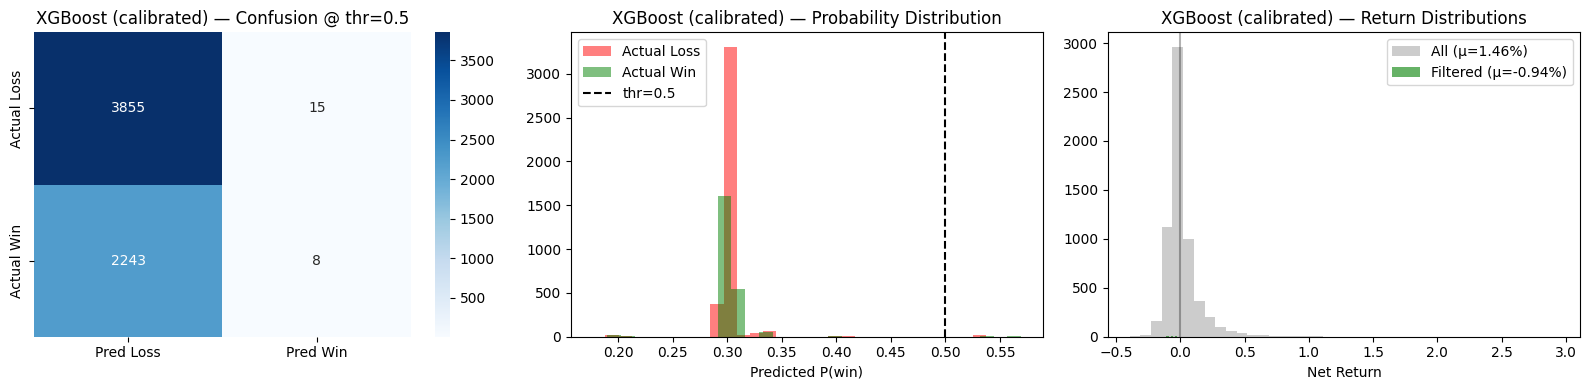


=== XGBoost Test Metrics ===
  auc               : 0.5001
  brier_score       : 0.2374
  precision         : 0.3478
  recall            : 0.0036
  f1                : 0.0070
  trades_taken      : 23
  trades_filtered   : 6098
  pct_filtered      : 0.9962
  base_mean_ret     : 0.0146
  filt_mean_ret     : -0.0094
  base_sharpe       : 1.5273
  filt_sharpe       : -1.0800
  sharpe_lift       : -2.6073


In [248]:
# === Train final XGBoost + Calibrate ===
# Chronological 80/20 split within training data:
#   X_es / y_es  → early-stopping training set
#   X_cal / y_cal → calibration set (model never trained on this)
_es_cut = int(len(X_train_scaled) * 0.80)
X_es,  y_es  = X_train_scaled.iloc[:_es_cut], y_train.iloc[:_es_cut]
X_cal, y_cal = X_train_scaled.iloc[_es_cut:], y_train.iloc[_es_cut:]
w_es = train_weights[:_es_cut]

final_xgb = XGBClassifier(
    **study_xgb.best_params,
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=1000,
    early_stopping_rounds=ES_ROUNDS,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=0,
)
final_xgb.fit(
    X_es, y_es,
    sample_weight=w_es,
    eval_set=[(X_cal, y_cal)],
    verbose=False,
)
print(f"XGBoost stopped at iteration {final_xgb.best_iteration} / 1000")

# cv='prefit': calibrate on held-out X_cal (model already fitted, no refitting)
calibrated_xgb = CalibratedClassifierCV(final_xgb, method='isotonic', cv='prefit')
calibrated_xgb.fit(X_cal, y_cal)

y_proba_xgb = calibrated_xgb.predict_proba(X_test_scaled)[:, 1]
metrics_xgb = plot_evaluation('XGBoost (ES + calibrated)', y_test, y_proba_xgb, returns_test, threshold=0.50)
print("\n=== XGBoost Test Metrics ===")
for k, v in metrics_xgb.items():
    print(f"  {k:18s}: {v:.4f}" if isinstance(v, float) else f"  {k:18s}: {v}")

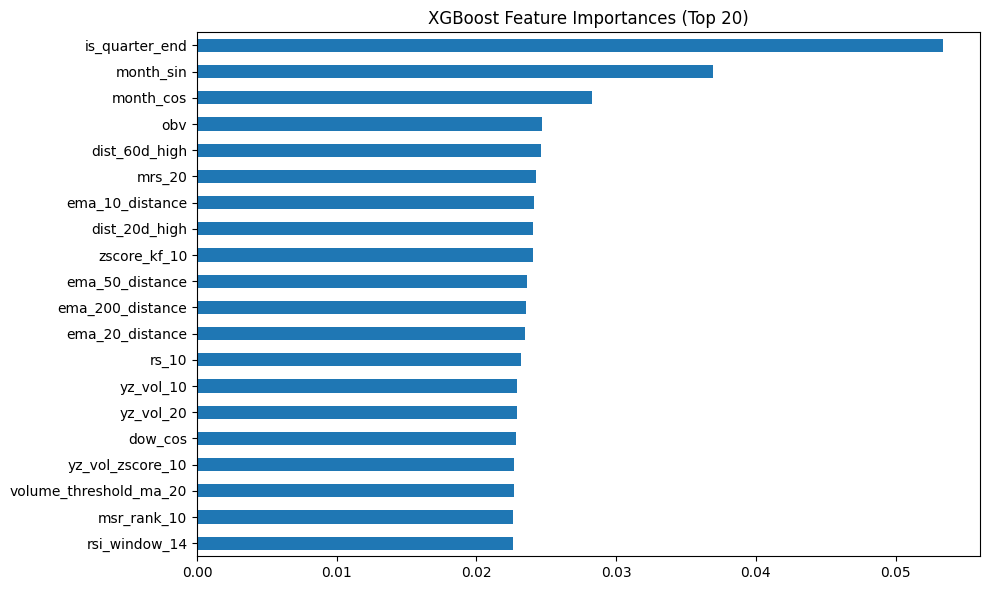

is_quarter_end            0.053380
month_sin                 0.036919
month_cos                 0.028254
obv                       0.024695
dist_60d_high             0.024620
mrs_20                    0.024288
ema_10_distance           0.024119
dist_20d_high             0.024082
zscore_kf_10              0.024046
ema_50_distance           0.023598
ema_200_distance          0.023529
ema_20_distance           0.023487
rs_10                     0.023178
yz_vol_10                 0.022898
yz_vol_20                 0.022893
dow_cos                   0.022860
yz_vol_zscore_10          0.022714
volume_threshold_ma_20    0.022679
msr_rank_10               0.022642
rsi_window_14             0.022618
yz_vol_zscore_20          0.022538
efi_zscore_20             0.022435
rsi_window_5              0.022430
vwap_distance_lowest      0.022139
kf_distance               0.021943
rsi_rank_14               0.021773
zscore_kf_20              0.021581
rs_20                     0.021392
mrs_overext_ratio   

In [249]:
# === Feature importance (from underlying XGBoost) ===
final_xgb.fit(X_train_scaled, y_train, sample_weight=train_weights)
fi_xgb = pd.Series(
    final_xgb.feature_importances_,
    index=X_train_scaled.columns,
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
fi_xgb.head(20).plot(kind='barh')
plt.title('XGBoost Feature Importances (Top 20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(fi_xgb)

# Save
os.makedirs('../models', exist_ok=True)
ts = datetime.now().strftime('%Y%m%d')
final_xgb.save_model(f'../models/xgboost_meta_{ts}.ubj')
print(f"\nSaved: ../models/xgboost_meta_{ts}.ubj")

# 12. Train LightGBM (same pipeline)

In [ ]:
from lightgbm import LGBMClassifier
from lightgbm import early_stopping as lgb_es, log_evaluation as lgb_log

def objective_lgbm(trial):
    params = {
        'objective':         'binary',
        'metric':            'auc',
        'n_estimators':      1000,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 63),
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'class_weight':      'balanced',
        'random_state':      42,
        'verbosity':         -1,
    }
    scores = []
    for train_idx, val_idx in purged_cv.split(X_train_scaled):
        m = LGBMClassifier(**params)
        m.fit(
            _rows(X_train_scaled, train_idx), _rows(y_train, train_idx),
            sample_weight=_rows(train_weights, train_idx),
            eval_set=[(_rows(X_train_scaled, val_idx), _rows(y_train, val_idx))],
            callbacks=[lgb_es(ES_ROUNDS, verbose=False), lgb_log(period=-1)],
        )
        proba = m.predict_proba(_rows(X_train_scaled, val_idx))[:, 1]
        scores.append(roc_auc_score(_rows(y_train, val_idx), proba))
    return np.mean(scores)

study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=80, show_progress_bar=True)

print(f"\nBest LGBM CV AUC: {study_lgbm.best_value:.4f}")
print("Best params:", study_lgbm.best_params)

[I 2026-05-01 14:35:19,801] A new study created in memory with name: no-name-abe760b3-20ad-45ed-a8bc-09dfd9fd3334


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-05-01 14:35:24,237] Trial 0 finished with value: 0.49992217846607 and parameters: {'n_estimators': 300, 'learning_rate': 0.17254716573280354, 'num_leaves': 50, 'max_depth': 5, 'min_child_samples': 21, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.08499808989183001, 'reg_lambda': 0.0006440507553993703}. Best is trial 0 with value: 0.49992217846607.
[I 2026-05-01 14:35:36,413] Trial 1 finished with value: 0.4897605679579266 and parameters: {'n_estimators': 450, 'learning_rate': 0.010636066512540286, 'num_leaves': 62, 'max_depth': 7, 'min_child_samples': 25, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 2.716051144654844e-06, 'reg_lambda': 0.00015777981883364995}. Best is trial 0 with value: 0.49992217846607.
[I 2026-05-01 14:35:38,164] Trial 2 finished with value: 0.49547833894084653 and parameters: {'n_estimators': 300, 'learning_rate': 0.023927528765580634, 'num_leaves': 44, 'max_depth': 3, 'min_ch

KeyboardInterrupt: 

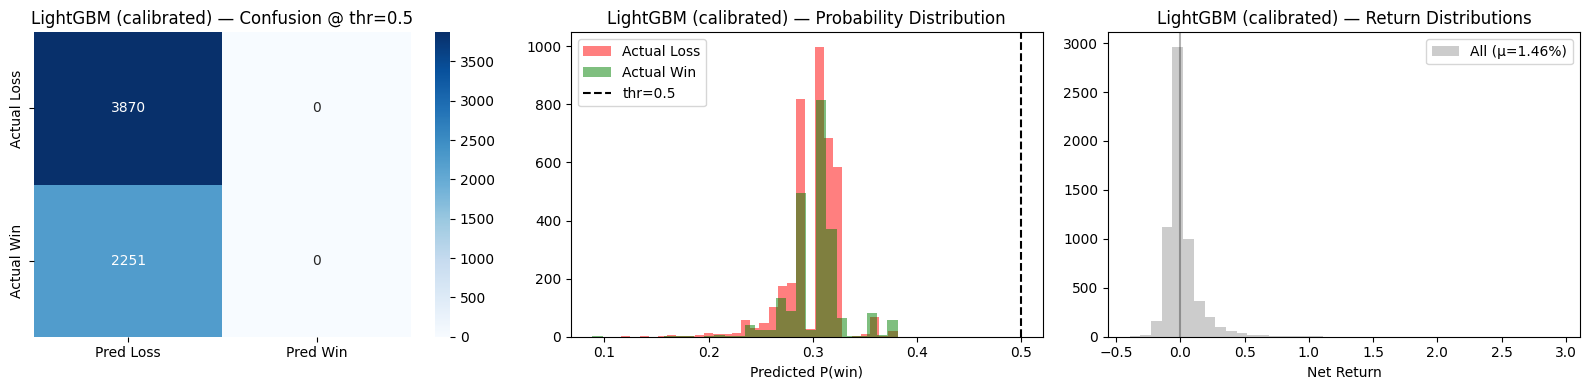

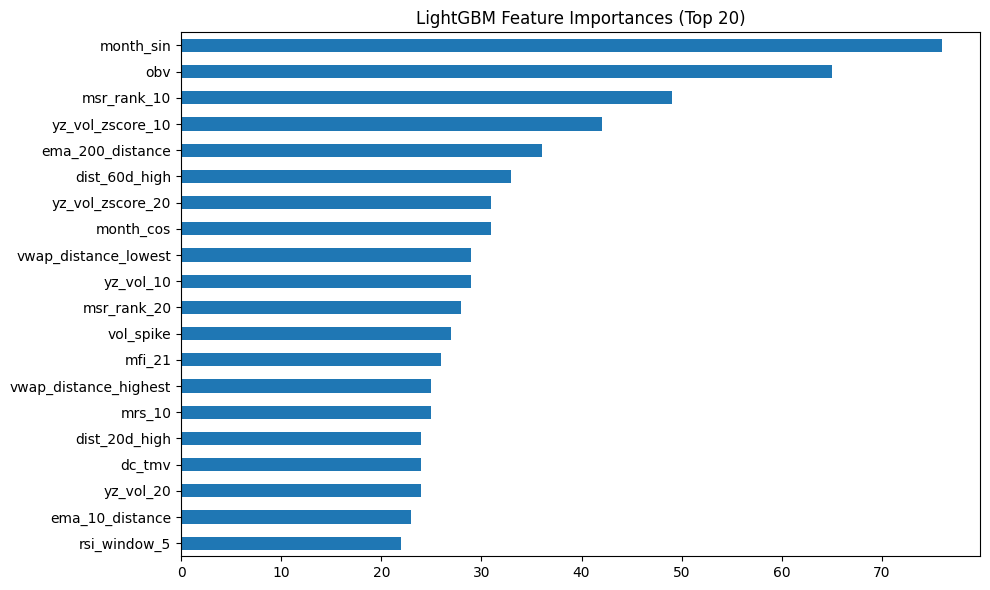


Saved: ../models/lightgbm_meta_20260501.txt


In [ ]:
final_lgbm = LGBMClassifier(
    **study_lgbm.best_params,
    objective='binary',
    n_estimators=1000,
    class_weight='balanced',
    random_state=42,
    verbosity=-1,
)
final_lgbm.fit(
    X_es, y_es,
    sample_weight=w_es,
    eval_set=[(X_cal, y_cal)],
    callbacks=[lgb_es(ES_ROUNDS, verbose=False), lgb_log(period=-1)],
)
print(f"LightGBM stopped at iteration {final_lgbm.best_iteration_} / 1000")

calibrated_lgbm = CalibratedClassifierCV(final_lgbm, method='isotonic', cv='prefit')
calibrated_lgbm.fit(X_cal, y_cal)

y_proba_lgbm = calibrated_lgbm.predict_proba(X_test_scaled)[:, 1]
metrics_lgbm = plot_evaluation('LightGBM (ES + calibrated)', y_test, y_proba_lgbm, returns_test, threshold=0.50)

# Feature importance
fi_lgbm = pd.Series(final_lgbm.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
fi_lgbm.head(20).plot(kind='barh')
plt.title('LightGBM Feature Importances (Top 20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

final_lgbm.booster_.save_model(f'../models/lightgbm_meta_{ts}.txt')
print(f"\nSaved: ../models/lightgbm_meta_{ts}.txt")

# 13. Train CatBoost (same pipeline)

In [ ]:
from catboost import CatBoostClassifier

def objective_cat(trial):
    params = {
        'objective':            'Logloss',
        'eval_metric':          'AUC',
        'iterations':           1000,
        'early_stopping_rounds': ES_ROUNDS,
        'learning_rate':        trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':                trial.suggest_int('depth', 3, 7),
        'l2_leaf_reg':          trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength':      trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'bagging_temperature':  trial.suggest_float('bagging_temperature', 0, 5),
        'auto_class_weights':   'Balanced',
        'random_seed':          42,
        'verbose':              False,
    }
    scores = []
    for train_idx, val_idx in purged_cv.split(X_train_scaled):
        m = CatBoostClassifier(**params)
        m.fit(
            _rows(X_train_scaled, train_idx), _rows(y_train, train_idx),
            sample_weight=_rows(train_weights, train_idx),
            eval_set=(_rows(X_train_scaled, val_idx), _rows(y_train, val_idx)),
        )
        proba = m.predict_proba(_rows(X_train_scaled, val_idx))[:, 1]
        scores.append(roc_auc_score(_rows(y_train, val_idx), proba))
    return float(np.mean(scores))

study_cat = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=60, show_progress_bar=True)

print(f"\nBest CatBoost CV AUC: {study_cat.best_value:.4f}")
print("Best params:", study_cat.best_params)

[I 2026-05-01 14:22:37,460] A new study created in memory with name: no-name-86ef3d1d-429d-4ada-92ea-355ff4935eae


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-05-01 14:22:40,127] Trial 0 finished with value: 0.5081156373886679 and parameters: {'iterations': 300, 'learning_rate': 0.17254716573280354, 'depth': 6, 'l2_leaf_reg': 0.24810409748678114, 'random_strength': 0.004207988669606638, 'bagging_temperature': 0.7799726016810132}. Best is trial 0 with value: 0.5081156373886679.
[I 2026-05-01 14:22:41,100] Trial 1 finished with value: 0.5102945982018718 and parameters: {'iterations': 100, 'learning_rate': 0.13394334706750485, 'depth': 6, 'l2_leaf_reg': 0.6796578090758157, 'random_strength': 0.0012087541473056963, 'bagging_temperature': 4.8495492608099715}. Best is trial 1 with value: 0.5102945982018718.
[I 2026-05-01 14:22:43,849] Trial 2 finished with value: 0.49608292139852506 and parameters: {'iterations': 550, 'learning_rate': 0.018891200276189398, 'depth': 3, 'l2_leaf_reg': 0.00541524411940254, 'random_strength': 0.016480446427978974, 'bagging_temperature': 2.6237821581611893}. Best is trial 1 with value: 0.5102945982018718.
[I 20

CalibratedClassifierCV skipped (CatBoost missing __sklearn_tags__). Run: pip install -U 'catboost>=1.2.9'. Using uncalibrated proba.


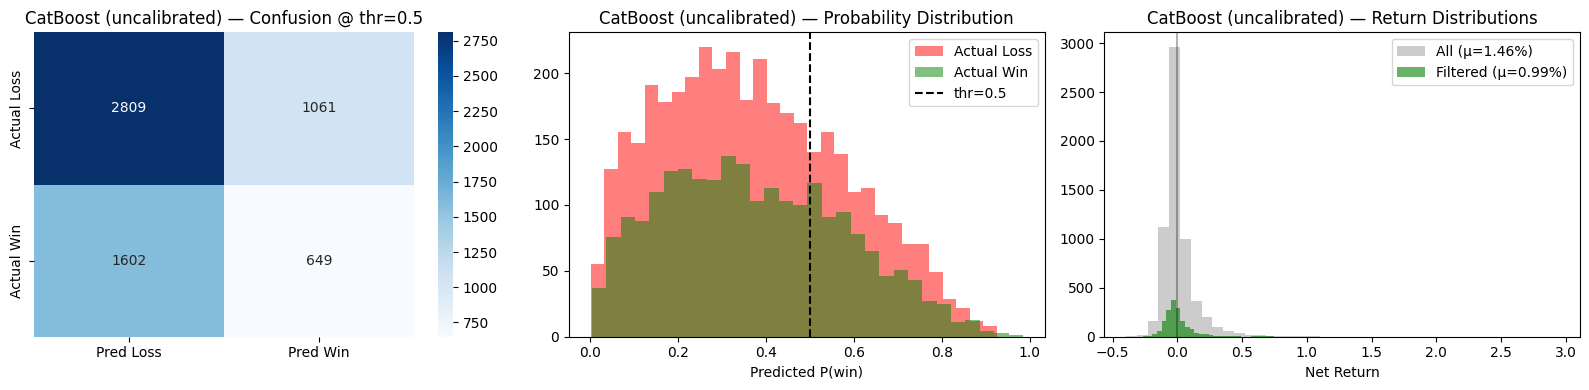

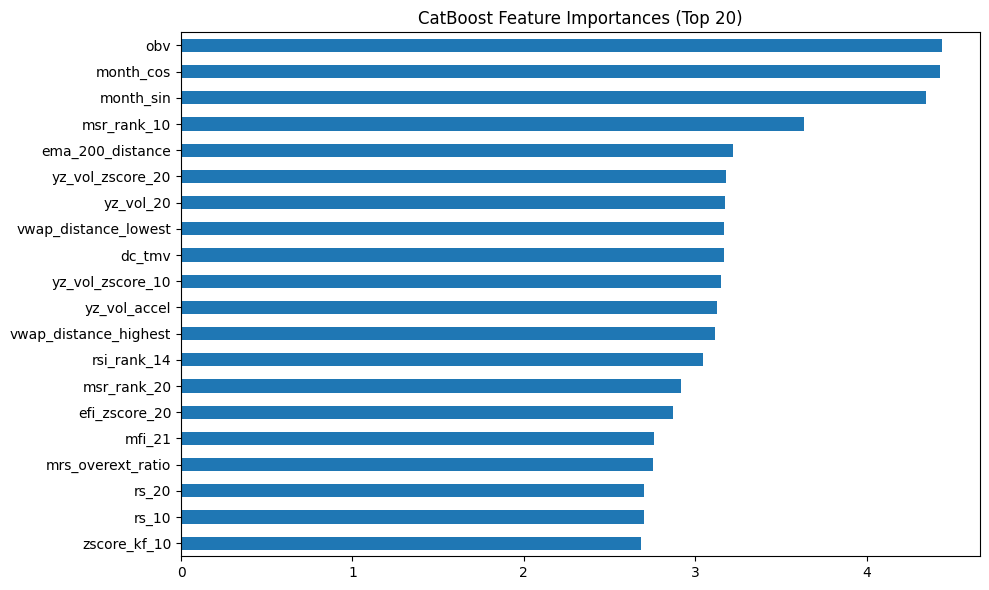


Saved: ../models/catboost_meta_20260501.cbm


In [ ]:
final_cat = CatBoostClassifier(
    **study_cat.best_params,
    objective='Logloss',
    iterations=1000,
    early_stopping_rounds=ES_ROUNDS,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=False,
)
final_cat.fit(
    X_es, y_es,
    sample_weight=w_es,
    eval_set=(X_cal, y_cal),
)
print(f"CatBoost stopped at iteration {final_cat.best_iteration_} / 1000")

try:
    calibrated_cat = CalibratedClassifierCV(final_cat, method='isotonic', cv='prefit')
    calibrated_cat.fit(X_cal, y_cal)
    y_proba_cat = calibrated_cat.predict_proba(X_test_scaled)[:, 1]
    cat_eval_name = 'CatBoost (ES + calibrated)'
except AttributeError as e:
    if '__sklearn_tags__' not in str(e):
        raise
    print("CalibratedClassifierCV skipped (upgrade catboost>=1.2.9). Using raw proba.")
    y_proba_cat = final_cat.predict_proba(X_test_scaled)[:, 1]
    cat_eval_name = 'CatBoost (ES + uncalibrated)'

metrics_cat = plot_evaluation(cat_eval_name, y_test, y_proba_cat, returns_test, threshold=0.50)

fi_cat = pd.Series(final_cat.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
fi_cat.head(20).plot(kind='barh')
plt.title('CatBoost Feature Importances (Top 20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

final_cat.save_model(f'../models/catboost_meta_{ts}.cbm')
print(f"\nSaved: ../models/catboost_meta_{ts}.cbm")

# 14. Model Comparison & Probability Threshold Analysis

Choose the **probability threshold** that maximizes Sharpe lift on the test set, not just accuracy.


In [ ]:
# === Side-by-side comparison ===
comparison = pd.DataFrame({
    'XGBoost':  metrics_xgb,
    'LightGBM': metrics_lgbm,
    'CatBoost': metrics_cat,
}).T

display_cols = ['auc', 'brier_score', 'precision', 'recall', 'f1',
                'trades_taken', 'pct_filtered',
                'base_mean_ret', 'filt_mean_ret',
                'base_sharpe', 'filt_sharpe', 'sharpe_lift']
print("=== Model Comparison (Test Set) ===")
print(comparison[display_cols].round(4))

=== Model Comparison (Test Set) ===
             auc  brier_score  precision  recall      f1  trades_taken  \
XGBoost   0.5027       0.2370     0.0000  0.0000  0.0000           0.0   
LightGBM  0.5252       0.2358     0.0000  0.0000  0.0000           0.0   
CatBoost  0.5068       0.2726     0.3795  0.2883  0.3277        1710.0   

          pct_filtered  base_mean_ret  filt_mean_ret  base_sharpe  \
XGBoost         1.0000         0.0146         0.0000       1.5273   
LightGBM        1.0000         0.0146         0.0000       1.5273   
CatBoost        0.7206         0.0146         0.0099       1.5273   

          filt_sharpe  sharpe_lift  
XGBoost        0.0000      -1.5273  
LightGBM       0.0000      -1.5273  
CatBoost       1.1734      -0.3539  


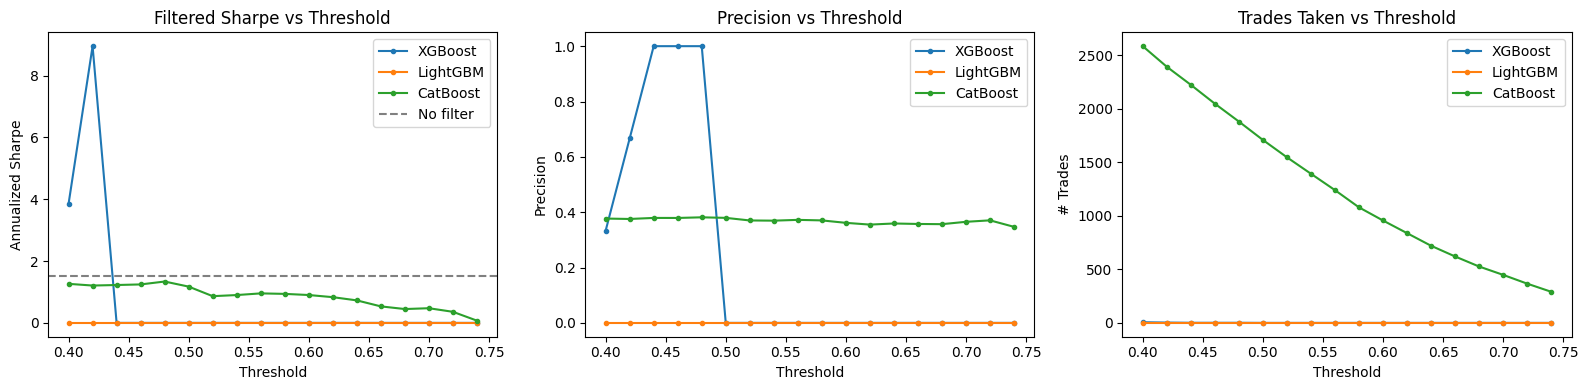


=== Optimal Threshold per Model (by filtered Sharpe) ===
XGBoost    | best thr=0.42 | filt_sharpe=8.953 | trades_taken=3 | precision=0.667
LightGBM   | best thr=0.40 | filt_sharpe=0.000 | trades_taken=0 | precision=0.000
CatBoost   | best thr=0.48 | filt_sharpe=1.338 | trades_taken=1882 | precision=0.382


In [ ]:
# === Threshold Sweep ===
def threshold_sweep(y_true, y_proba, returns, thresholds=np.arange(0.40, 0.75, 0.02)):
    rows = []
    for thr in thresholds:
        m = evaluate_meta_model(y_true, y_proba, returns, threshold=thr)
        m['threshold'] = thr
        rows.append(m)
    return pd.DataFrame(rows)

sweeps = {
    'XGBoost':  threshold_sweep(y_test, y_proba_xgb,  returns_test),
    'LightGBM': threshold_sweep(y_test, y_proba_lgbm, returns_test),
    'CatBoost': threshold_sweep(y_test, y_proba_cat,  returns_test),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for name, sweep in sweeps.items():
    axes[0].plot(sweep['threshold'], sweep['filt_sharpe'], label=name, marker='o', markersize=3)
    axes[1].plot(sweep['threshold'], sweep['precision'],   label=name, marker='o', markersize=3)
    axes[2].plot(sweep['threshold'], sweep['trades_taken'], label=name, marker='o', markersize=3)

# Reference: base (no-filter) Sharpe
axes[0].axhline(metrics_xgb['base_sharpe'], color='gray', linestyle='--', label='No filter')
axes[0].set_title('Filtered Sharpe vs Threshold')
axes[0].set_xlabel('Threshold');  axes[0].set_ylabel('Annualized Sharpe');  axes[0].legend()

axes[1].set_title('Precision vs Threshold')
axes[1].set_xlabel('Threshold');  axes[1].set_ylabel('Precision');  axes[1].legend()

axes[2].set_title('Trades Taken vs Threshold')
axes[2].set_xlabel('Threshold');  axes[2].set_ylabel('# Trades');  axes[2].legend()

plt.tight_layout()
plt.show()

# Best threshold per model (by Sharpe lift)
print("\n=== Optimal Threshold per Model (by filtered Sharpe) ===")
for name, sweep in sweeps.items():
    best = sweep.loc[sweep['filt_sharpe'].idxmax()]
    print(f"{name:10s} | best thr={best['threshold']:.2f} | "
          f"filt_sharpe={best['filt_sharpe']:.3f} | "
          f"trades_taken={int(best['trades_taken'])} | "
          f"precision={best['precision']:.3f}")

# 15. Calibration Quality

A well-calibrated model has predicted probabilities that match observed frequencies. This matters because **position sizing should use calibrated probabilities** (e.g., for Kelly sizing).


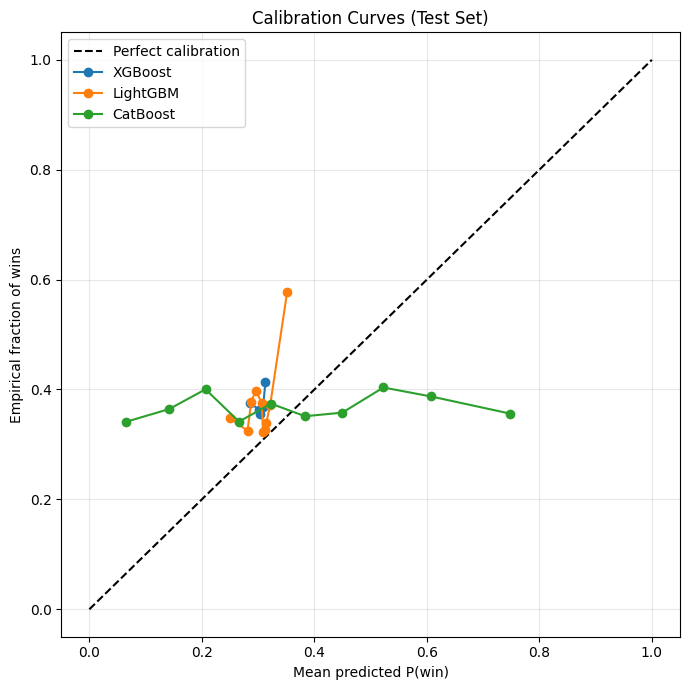

In [ ]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

for name, proba in [('XGBoost', y_proba_xgb),
                    ('LightGBM', y_proba_lgbm),
                    ('CatBoost', y_proba_cat)]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)

ax.set_xlabel('Mean predicted P(win)')
ax.set_ylabel('Empirical fraction of wins')
ax.set_title('Calibration Curves (Test Set)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 16. Position Sizing via Calibrated Probabilities

Now that probabilities are calibrated, we can use them for **Kelly-style sizing**.


Train avg win:  18.182%
Train avg loss: -5.544%
Win/Loss ratio: 3.28


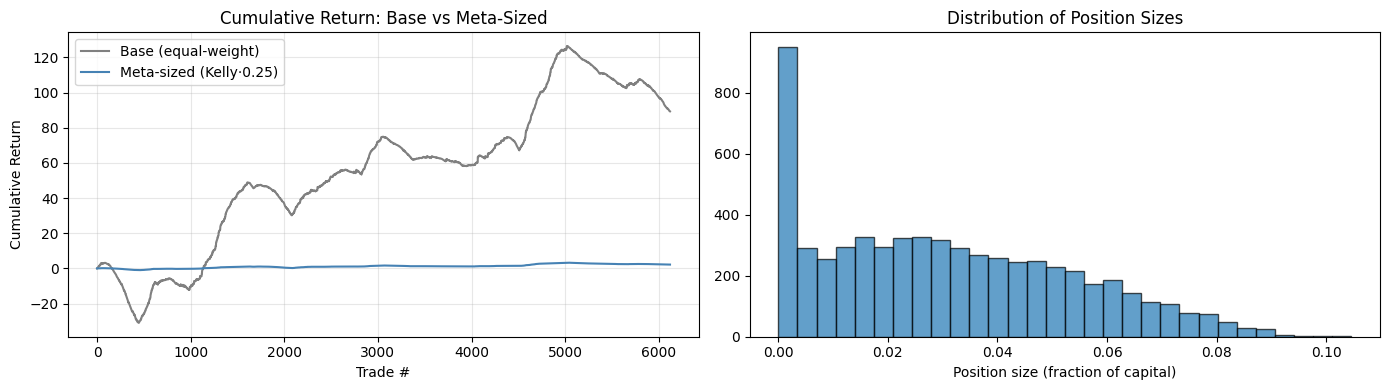


Base returns:    Sharpe=1.527
Sized returns:   Sharpe=1.079
% trades sized > 0: 88.4%


In [ ]:
def kelly_size(p_win: np.ndarray, avg_win: float, avg_loss: float, kelly_fraction: float = 0.25):
    """
    Compute fractional-Kelly position size given calibrated win probability.
    avg_win, avg_loss should be POSITIVE numbers (use abs of avg loss).
    Returns size in [0, kelly_fraction].
    """
    b = avg_win / max(avg_loss, 1e-9)
    f = (p_win * (b + 1) - 1) / b
    return np.clip(f, 0, 1) * kelly_fraction

# Use historical avg win/loss from training
train_winners = training_df.loc[train_mask & (training_df['Y']==1), 'net_return']
train_losers  = training_df.loc[train_mask & (training_df['Y']==0), 'net_return']
avg_win  = train_winners.mean()
avg_loss = abs(train_losers.mean())

print(f"Train avg win:  {avg_win:.3%}")
print(f"Train avg loss: -{avg_loss:.3%}")
print(f"Win/Loss ratio: {avg_win/avg_loss:.2f}")

# Apply to test set using ENSEMBLE probability
ensemble_proba = (y_proba_xgb + y_proba_lgbm + y_proba_cat) / 3
sizes = kelly_size(ensemble_proba, avg_win, avg_loss, kelly_fraction=0.25)

# Sized P&L
sized_returns = sizes * returns_test.values

# Compare base (equal weight) vs sized
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(np.cumsum(returns_test.values), label='Base (equal-weight)', color='gray')
ax[0].plot(np.cumsum(sized_returns), label='Meta-sized (Kelly·0.25)', color='steelblue')
ax[0].set_title('Cumulative Return: Base vs Meta-Sized')
ax[0].set_xlabel('Trade #')
ax[0].set_ylabel('Cumulative Return')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].hist(sizes, bins=30, edgecolor='black', alpha=0.7)
ax[1].set_title('Distribution of Position Sizes')
ax[1].set_xlabel('Position size (fraction of capital)')
plt.tight_layout()
plt.show()

print(f"\nBase returns:    Sharpe={returns_test.mean()/(returns_test.std()+1e-9)*np.sqrt(252):.3f}")
print(f"Sized returns:   Sharpe={pd.Series(sized_returns).mean()/(pd.Series(sized_returns).std()+1e-9)*np.sqrt(252):.3f}")
print(f"% trades sized > 0: {(sizes > 0).mean()*100:.1f}%")

# 17. Save Calibrated Models + Scaler

In [ ]:
import joblib

artifacts_dir = '../models'
os.makedirs(artifacts_dir, exist_ok=True)
ts = datetime.now().strftime('%Y%m%d')

# Save calibrated models (these output proper probabilities)
joblib.dump(calibrated_xgb,  f'{artifacts_dir}/calibrated_xgb_{ts}.joblib')
joblib.dump(calibrated_lgbm, f'{artifacts_dir}/calibrated_lgbm_{ts}.joblib')
joblib.dump(calibrated_cat,  f'{artifacts_dir}/calibrated_cat_{ts}.joblib')

# Save scaler + feature columns (essential for inference)
joblib.dump(scaler, f'{artifacts_dir}/scaler_{ts}.joblib')

with open(f'{artifacts_dir}/feature_columns_{ts}.json', 'w') as f:
    json.dump({
        'features':     training_feature_columns,
        'train_end':    TRAIN_END_DATE,
        'cost':         ROUND_TRIP_COST,
        'edge':         MIN_RETURN_EDGE,
        'embargo_days': EMBARGO_DAYS,
    }, f, indent=2)

print(f"All artifacts saved to {artifacts_dir}/ with timestamp {ts}")

All artifacts saved to ../models/ with timestamp 20260501


# 📋 Summary of Changes

| # | Issue (Original) | Fix Applied |
|---|---|---|
| 1 | `train_test_split(shuffle=True)` | Chronological split with embargo |
| 2 | `next_5d_*`, `next_3d_*` features | Removed all look-ahead features |
| 3 | SMOTE on time-series data | `class_weight='balanced'` / `scale_pos_weight` |
| 4 | Standard K-Fold CV | Purged & Embargoed K-Fold |
| 5 | No sample weights | López de Prado uniqueness weights |
| 6 | Raw probabilities | Isotonic calibration |
| 7 | Accuracy-driven optimization | AUC + Sharpe-lift driven |
| 8 | `Y = return > 0` | Net return > threshold (with costs) |
| 9 | No threshold analysis | Sweep + ensemble + Kelly sizing |
| 10 | No effective sample size check | Compute & report |

## 🚦 Next Steps

1. **Walk-forward validation** — re-train every quarter, test on next quarter
2. **SHAP analysis** — understand WHY each trade is filtered
3. **Live shadow testing** — paper trade meta-filtered signals for 1-3 months before going live
4. **Re-training cadence** — alpha decays; re-train every 3-6 months
5. **Ensemble weighting** — try stacking instead of simple average

## ⚠️ Honest Expectations

- OOS AUC of 0.55-0.62 is realistic for VN equity meta-labeling
- Sharpe lift of 0.2-0.5 is a good outcome
- Expect 30-50% degradation from backtest to live
- If AUC > 0.70, **suspect leakage** — re-audit features
